In [933]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint

In [934]:
fn_yaml = "config.yaml"

config = yaml.safe_load(open(fn_yaml, 'r'))
pprint(config)



{'derived_signals': {'sig4': {'equation': 'sig1 + sig2',
                              'signal_name': 'signal_4',
                              'units': 'F'}},
 'ramp_config': {'end_time': {'value': 10},
                 'hold_duration': {'max_value': 10, 'min_value': 0},
                 'ramp_duration': {'max_value': 5, 'min_value': 0},
                 'ramp_start': {'max_value': 5, 'min_value': 1}},
 'signals': {'sig1': {'max_rate_of_change': 10,
                      'max_value': 100,
                      'min_value': 0,
                      'signal_name': 'signal_1',
                      'units': 'F'},
             'sig2': {'max_rate_of_change': 10,
                      'max_value': 200,
                      'min_value': 0,
                      'signal_name': 'signal_2',
                      'units': 'F'},
             'sig3': {'max_rate_of_change': 1,
                      'max_value': 300,
                      'min_value': 0,
                      'signal_name': 'signal

In [935]:


def get_sample(d, sample_type = 'uniform'):

    if sample_type == 'uniform':
        return np.random.uniform(d['min_value'], d['max_value'])
    else:
        raise ValueError(f"Unsupported sample_type: {sample_type}")

def generate_signal(signal_name, signal_config, ramp_config, end_time_pad = 1):

    initial_value = get_sample(signal_config)
    ramp_start = get_sample(ramp_config['ramp_start'])
    ramp_duration =  get_sample(ramp_config['ramp_duration'])
    ramp_rate = np.random.uniform(-signal_config['max_rate_of_change'], signal_config['max_rate_of_change'])
    end_time = ramp_config['end_time']['value']
    hold_duration = get_sample(ramp_config['hold_duration'])

    t0 = 0
    t1 = ramp_start
    t2 = t1 + ramp_duration
    t3 = t2 + hold_duration
    t4 = t3 + ramp_duration
    t5 = np.max([t4 + end_time_pad, end_time])

    y0 = initial_value
    y1 = initial_value
    y2 = y1 + ramp_rate * ramp_duration
    y3 = y2
    y4 = y3 - ramp_rate * ramp_duration
    y5 = y4

    t = np.array([t0, t1, t2, t3, t4, t5])
    y = np.array([y0, y1, y2, y3, y4, y5])

    y = np.clip(y, signal_config['min_value'], signal_config['max_value'])
    df = pd.DataFrame(index = t, data = {signal_name: y})

    if end_time not in df.index:
        df.loc[end_time] = np.nan
        df = df.sort_index()
        df = df.interpolate(method = 'index')

    parameters = {
        'initial_value': initial_value,
        'ramp_start': ramp_start,
        'ramp_duration': ramp_duration,
        'ramp_rate': ramp_rate,
        'end_time': end_time,
        'hold_duration': hold_duration
    }
  
    return df, parameters


def generate_signals(config):

    dfs = []
    parameters = {}

    for signal_name, signal_config in config['signals'].items():
        df, params = generate_signal(signal_name, signal_config, config['ramp_config'])
        dfs.append(df)
        parameters[signal_name] = params

    df_merged = pd.concat(dfs, axis = 1)
    df_merged = df_merged.sort_index()
    df_merged = df_merged.interpolate(method = 'index')

    I = df_merged.index <= config['ramp_config']['end_time']['value']
    df_merged = df_merged.loc[I]

    return df_merged, parameters


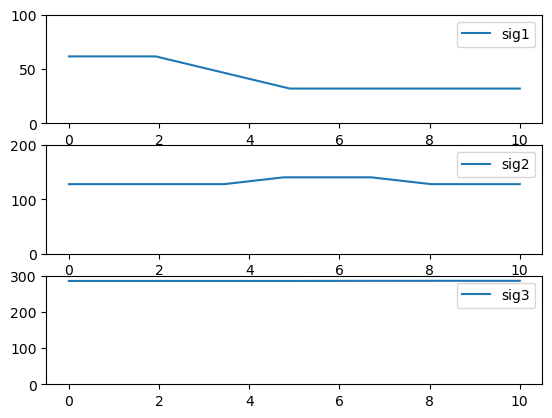

In [991]:

df_merged, parameters = generate_signals(config)

fig, ax = plt.subplots(len(df_merged.columns))
for i, signal_name in enumerate(df_merged.columns):
    ax[i].plot(df_merged.index, df_merged[signal_name], label = f'{signal_name}')
    ax[i].set_ylim(config['signals'][signal_name]['min_value'], config['signals'][signal_name]['max_value'])
    ax[i].legend(loc = 1)